## Assignment 2 – Julia Widén
Python Programming for Business Intelligence

## Task 0

#### a)
The dataset used is the **Customer Purchase Behavior Analysis** dataset from Kaggle.
-> [Customer Purchase Behavior Analysis](https://www.kaggle.com/datasets/arfeenkabir/customer-purchase-behavior-analysis)

#### b)
The dataset contains 3,900 rows and 19 columns covering customer purchase behavior. Variables include customer demographics (age, gender, location), purchase details (item, category, amount, season), and engagement metrics (review rating, subscription status, discount usage, purchase frequency). The goal would be to analyze purchasing patterns and identify what drives customer spending.

#### c)

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3900.00,3900.00,3900.00
mean,1950.50,44.07,59.76,3.75,25.35
std,1125.98,15.21,23.69,0.72,14.45
min,1.00,18.00,20.00,2.50,1.00
25%,975.75,31.00,39.00,3.10,13.00
50%,1950.50,44.00,60.00,3.70,25.00
75%,2925.25,57.00,81.00,4.40,38.00
max,3900.00,70.00,100.00,5.00,50.00


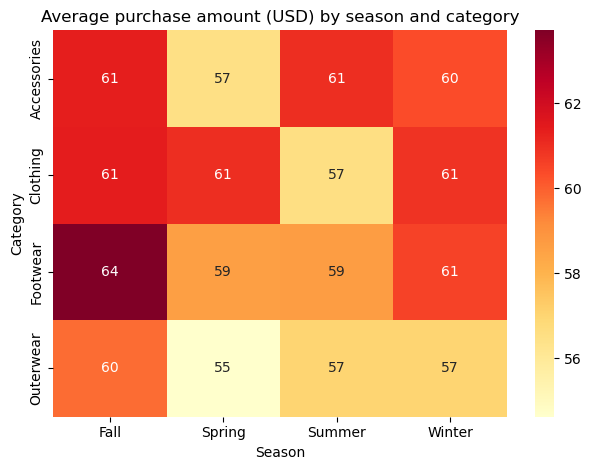

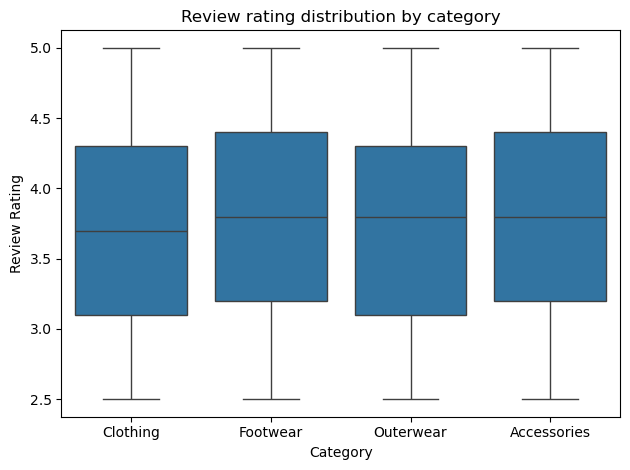

In [1]:
# c)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/shopping_trends.csv')

# summary statistics
display(df.describe().round(2))

# visualization 1: heatmap of average purchase amount by season and category
pivot = df.pivot_table(index='Category', columns='Season', values='Purchase Amount (USD)', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Average purchase amount (USD) by season and category')
plt.xlabel('Season')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# visualization 2: review rating distribution by category
sns.boxplot(data=df, x='Category', y='Review Rating')
plt.title('Review rating distribution by category')
plt.xlabel('Category')
plt.ylabel('Review Rating')
plt.tight_layout()
plt.show()

### Task 1

In [2]:
from dotenv import load_dotenv     # importing the tool that can read .env files
import os                     

load_dotenv()     # loading all variables from the .env file

api_key = os.environ.get("MARKETSTACK_API_KEY")     # reading the API key

print(api_key[:5] + "...")     # printing only the first 5 characters to confirm it loaded correctly

63729...


### Task 2

In [3]:
import requests
import pandas as pd

# a)
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]     # defining the five FAANG ticker symbols
all_data = []

# looping thorugh each ticker and fetching EOD data for March 2026
for ticker in tickers:
    url = "https://api.marketstack.com/v1/eod"
    params = {
        "access_key" : api_key,
        "symbols" : ticker,
        "date_from" : "2026-03-01",
        "date_to" : "2026-03-31",
        "limit": 31
    }
    response = requests.get(url, params=params)
    print(f"{ticker} - Status code: {response.status_code}")
    
# extracting the data from the JSON response and adding to the list
    data = response.json()["data"]
    all_data.extend(data)

#printing result
print(f"\nTotal rows retrieved: {len(all_data)}")

META - Status code: 200
AAPL - Status code: 200
AMZN - Status code: 200
NFLX - Status code: 200
GOOG - Status code: 200

Total rows retrieved: 110


In [4]:
# b)

df = pd.DataFrame(all_data)                                       
df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')     # converting the date into a clear year-month-day format   
df = df.sort_values('date').reset_index(drop=True)               
display(df.head())    

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,GOOG,XNAS,2026-03-02
1,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NFLX,XNAS,2026-03-02
2,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,META,ARCX,2026-03-02
3,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
4,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,AMZN,XNAS,2026-03-02


In [5]:
# c)

# summary statistics for closing prices grouped by stock
summary = df.groupby('symbol')['close'].describe()
display(summary)

# calculating return percentage for each stock
returns = {}
for ticker in tickers:
    stock = df[df['symbol'] == ticker].sort_values('date')
    first_close = stock['close'].iloc[0]
    last_close = stock['close'].iloc[-1]
    ret = (last_close - first_close) / first_close * 100
    returns[ticker] = ret

# displaying returns as a df
returns_df = pd.DataFrame.from_dict(returns, orient='index', columns=['return_%'])
returns_df.index.name = 'symbol'
display(returns_df.round(2))     # rounding to two decimals for clearer display 
print()     # printing empty line for clearer display

# reportorting the best and worst performing stock
best = max(returns, key=returns.get)
worst = min(returns, key=returns.get)
print(f"Best performing stock in March 2026: {best} ({returns[best]:.2f}%)")
print(f"Worst performing stock in March 2026: {worst} ({returns[worst]:.2f}%)")

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


,return_%
symbol,
META,-12.46
AAPL,-4.13
AMZN,-0.06
NFLX,-0.97
GOOG,-6.37



Best performing stock in March 2026: AMZN (-0.06%)
Worst performing stock in March 2026: META (-12.46%)


### Task 3

In [6]:
# setup for task 3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_theme()      # apply seaborn's default theme to all plots

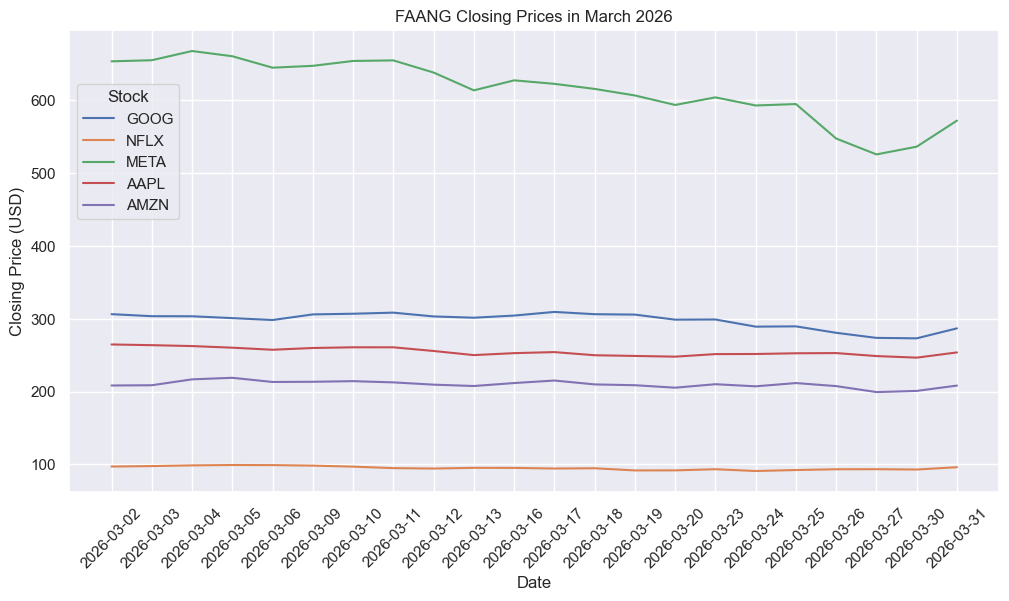

In [7]:
# a)

# creating line chart of closing prices over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='close', hue='symbol')
plt.title('FAANG Closing Prices in March 2026')     # adding descriptive title
plt.xlabel('Date')     # date for x-axis
plt.ylabel('Closing Price (USD)')     # closing price for y-axis
plt.xticks(rotation=45)     # rotating for clearer visibility
plt.legend(title='Stock', loc='upper left', bbox_to_anchor=(0, 0.90))     # customizing legend for clearer visibility
plt.show()

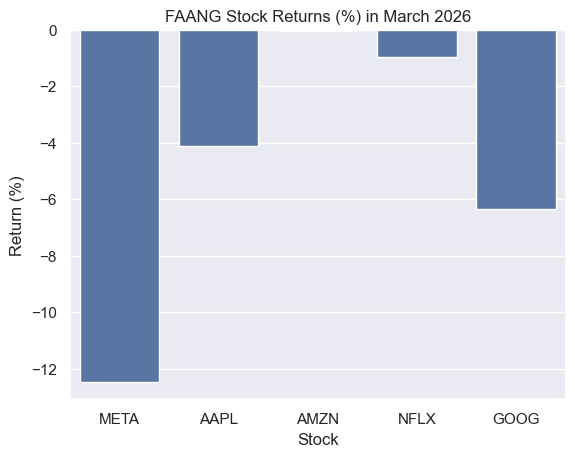

In [8]:
# b)

sns.barplot(data=returns_df, x='symbol', y='return_%')
plt.title('FAANG Stock Returns (%) in March 2026')
plt.xlabel('Stock')
plt.ylabel('Return (%)')
plt.show()

# comment: AMZN bar is almost not visible, but is in line with the return -0.06%

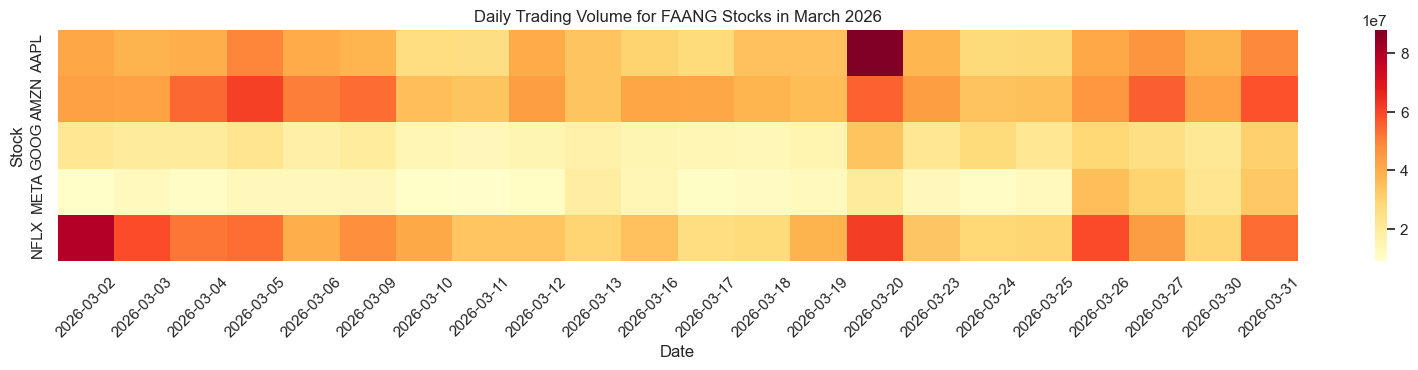

In [9]:
# c)

# pivoting the data into a stocks x dates matrix
volume_pivot = df.pivot(index='symbol', columns='date', values='volume')

# plotting the heatmap showing the daily trading volume for each stock
plt.figure(figsize=(20, 3))
sns.heatmap(volume_pivot,cmap='YlOrRd')     # skipping annot=True due to the clutter it causes because the trading volume is huge
plt.title('Daily Trading Volume for FAANG Stocks in March 2026')
plt.xlabel('Date')
plt.ylabel('Stock')
plt.xticks(rotation=45)     # rotating for clearer visibility
plt.show()

### Task 4

In [10]:
# a)
import os
import json

# create the exports folder if it doesn't exist
os.makedirs('exports', exist_ok=True)

# export the cleaned df as JSON
with open('exports/stockdata.json', 'w') as f:
    json.dump(df.to_dict(orient='records'), f, indent=2)

print('Exported JSON data to exports/stockdata.json')

Exported JSON data to exports/stockdata.json


In [11]:
# b)

# exportoring the df to a CSV file
df.to_csv('exports/stockdata.csv', index=False)

print('Exported DataFrame to exports/stockdata.csv')

Exported DataFrame to exports/stockdata.csv


In [12]:
# c)

# loading back the JSON file
with open('exports/stockdata.json', 'r') as f:
    loaded_json = json.load(f)

print('First 5 rows of loaded JSON data:')
display(pd.DataFrame(loaded_json).head())

# loading back the CSV file
loaded_csv = pd.read_csv('exports/stockdata.csv')

print('\nFirst 5 rows of loaded CSV data:')
display(loaded_csv.head())

First 5 rows of loaded JSON data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,GOOG,XNAS,2026-03-02
1,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NFLX,XNAS,2026-03-02
2,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,META,ARCX,2026-03-02
3,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
4,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,AMZN,XNAS,2026-03-02



First 5 rows of loaded CSV data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,GOOG,XNAS,2026-03-02
1,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NFLX,XNAS,2026-03-02
2,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,META,ARCX,2026-03-02
3,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
4,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,AMZN,XNAS,2026-03-02


## Task 5

In [13]:
# a)

import sqlite3

# connecting to the northwind database
connection = sqlite3.connect('data/northwind.db')
db = connection.cursor()

# listing all tables in the database
db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

for table in tables:
    print(table[0])

Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [14]:
# b)

import pandas as pd

# retrieving all products with a unit price over 30
df_products = pd.read_sql_query(
    "SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30",
    connection
)

display(df_products)

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [15]:
# c)

# retrieving all orders shipped to Germany
df_orders = pd.read_sql_query(
    """
    SELECT c.CompanyName,
           o.OrderID,
           o.OrderDate,
           o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN 'Order Details' od ON o.OrderID = od.OrderID
    WHERE o.ShipCountry = 'Germany'
    """,
    connection
)
display(df_orders)

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


## Task 6

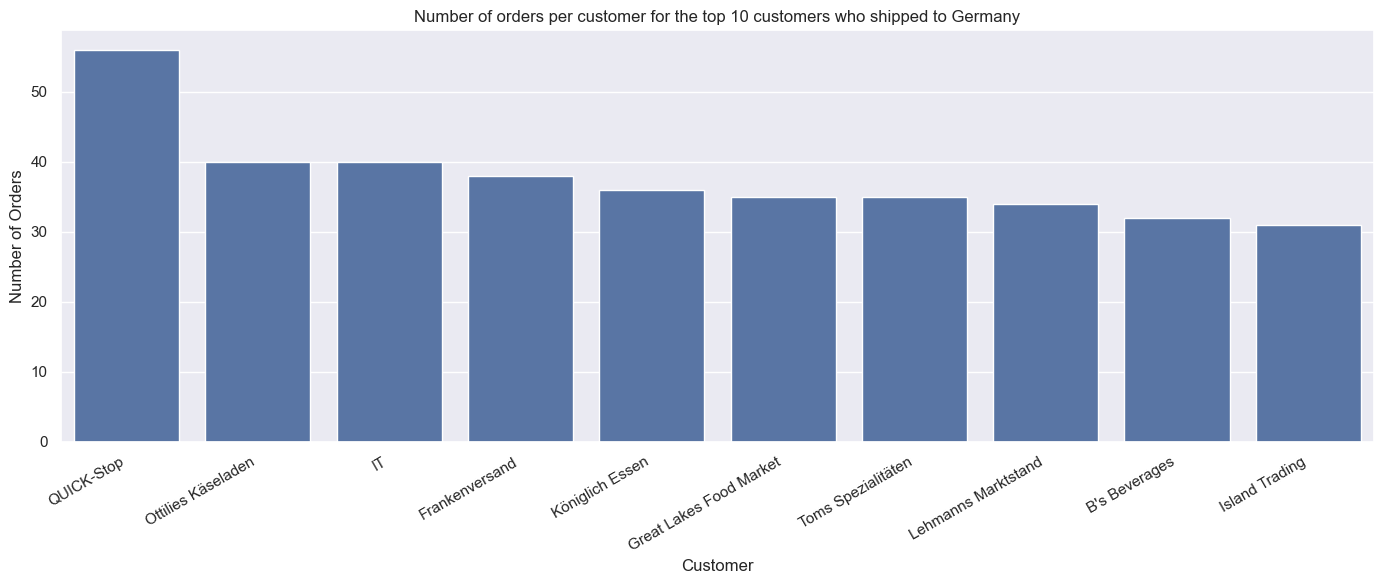

In [16]:
# a)

# counting unique orders per customer and selecting the top 10
top10 = df_orders.groupby('CompanyName')['OrderID'].nunique().sort_values(ascending=False).head(10).reset_index()     # grouping by customer, counting per customer orders, sorting by most orders and keeping top 10

top10.columns = ['CompanyName', 'OrderCount']

# creating a bar plot showing number of orders per customer
plt.figure(figsize=(14, 6))
sns.barplot(data=top10, x='CompanyName', y='OrderCount')
plt.title('Number of orders per customer for the top 10 customers who shipped to Germany')
plt.xlabel('Customer')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()     # making sure nothing is lost in the plot
plt.show()

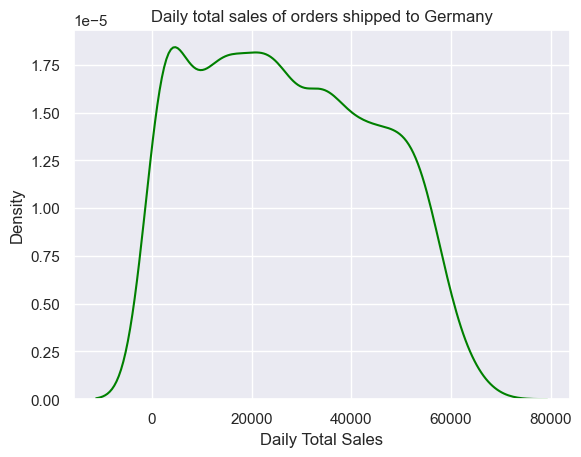

In [17]:
# b)

# computing total sales per order date
daily_sales = df_orders.groupby('OrderDate')['LineTotal'].sum().reset_index()

# creating density plot of daily total sales for orders shipped to Germany
sns.kdeplot(data=daily_sales, x='LineTotal', color='green')     # making the line green for funsies
plt.title('Daily total sales of orders shipped to Germany')
plt.xlabel('Daily Total Sales')
plt.ylabel('Density')
plt.show()

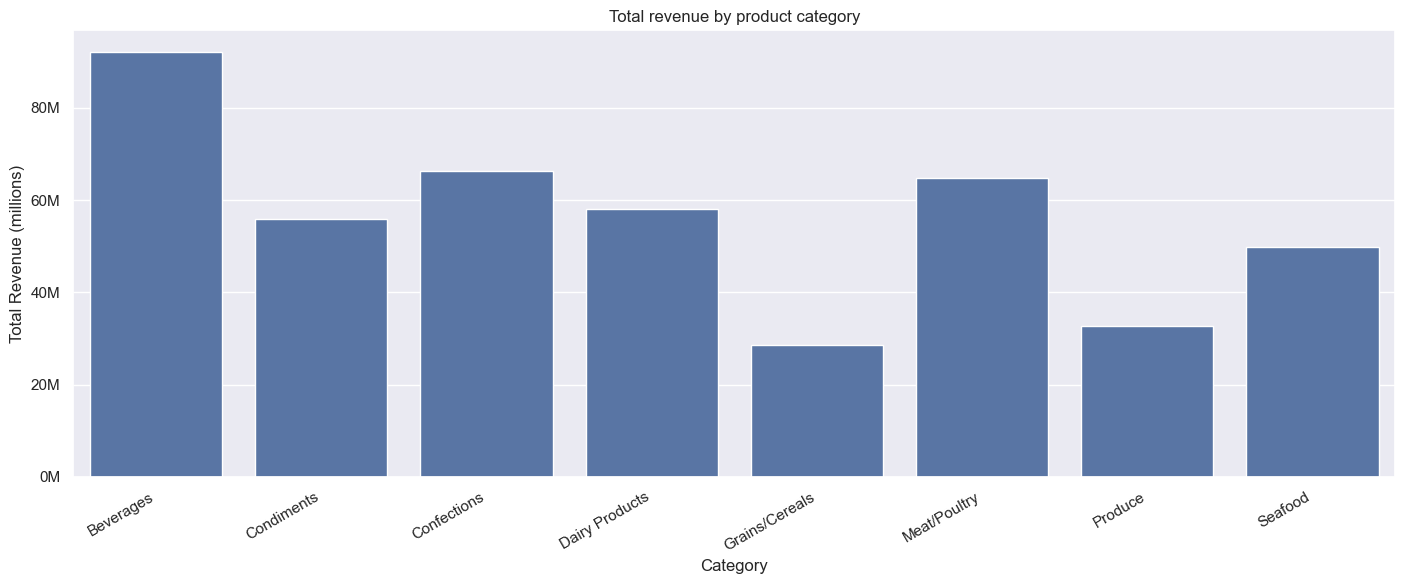

In [18]:
# c)

# querying total revenue per product category
df_revenue = pd.read_sql_query(
    """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
    """,
    connection
)

# creating bar plot showing total revenue by category
plt.figure(figsize=(14, 6))
sns.barplot(data=df_revenue, x='CategoryName', y='TotalRevenue')
plt.title('Total revenue by product category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (millions)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))     # !!! using AI to generate code that formats the y-axis the due to numbers being so large 
plt.show()

## Task 7

In [19]:
# a)

# retrieving the full Products and Categories tables into dfs
df_products_full = pd.read_sql_query("SELECT * FROM Products", connection)
df_categories = pd.read_sql_query("SELECT * FROM Categories", connection)

print('Products:')
display(df_products_full.head())

print('Categories:')
display(df_categories.head())

Products:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [20]:
# b)

# performing an inner join on the two df on CategoryID
inner = df_products_full.merge(df_categories, on='CategoryID', how='inner')
display(inner.head())     # displaying to check our code worked

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.0,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.0,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,24,Guaraná Fantástica,10,1,12 - 355 ml cans,4.5,20,0,0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,34,Sasquatch Ale,16,1,24 - 12 oz bottles,14.0,111,0,15,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,35,Steeleye Stout,16,1,24 - 12 oz bottles,18.0,20,0,15,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [21]:
# c) comment on result: as expected SQL approach is way faster

In [22]:
%%time

# timing the SQL approach from task 6c
df_revenue_sql = pd.read_sql_query(
    """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
    """,
    connection
)

CPU times: user 591 ms, sys: 24.9 ms, total: 616 ms
Wall time: 297 ms


In [23]:
%%time

# timing the pandas approach
df_orderdetails = pd.read_sql_query("SELECT * FROM 'Order Details'", connection)
df_merged_7c = df_orderdetails.merge(df_products_full, on='ProductID').merge(df_categories, on='CategoryID')
df_merged_7c['TotalRevenue'] = df_merged_7c['UnitPrice_x'] * df_merged_7c['Quantity']
df_revenue_pandas = df_merged_7c.groupby('CategoryName')['TotalRevenue'].sum()

CPU times: user 650 ms, sys: 84 ms, total: 734 ms
Wall time: 766 ms


## Task 8

In [24]:
# setup for task 8

# creating the two datasets as given in the task
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [25]:
# a)

print('Before:')
display(wide_data)

wide_to_long = wide_data.melt(
        id_vars='store', 
        var_name='quarter', 
        value_name='sales'
)

print()

print('After:')
display(wide_to_long)

Before:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500



After:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [26]:
# b)

print('Before:')
display(long_data)

long_to_wide = long_data.pivot(
    index='product',
    columns='month',
    values='units_sold'
).rename_axis(columns=None).reset_index()
long_to_wide = long_to_wide[['product', 'Jan', 'Feb', 'Mar']]     # reordering columns chronologically

print()
print('After:')
display(long_to_wide)

Before:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130



After:


,product,Jan,Feb,Mar
0,Laptop,45,50,55
1,Phone,120,110,130


In [27]:
# c)

# printing the transformed dataset from a)
print('Before (transformed wide_to_long):')
display(wide_to_long)

long_back_to_wide = wide_to_long.pivot(     # pivoting back to wide format
    index='store',
    columns='quarter',
    values='sales'
).rename_axis(columns=None).reset_index()

print()
print('After (back to original wide format):')     # printing wide format
display(long_back_to_wide)

Before (transformed wide_to_long):


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000



After (back to original wide format):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [28]:
# printing the transformed dataset from b)
print('Before (transformed long_to_wide):')  
display(long_to_wide)

wide_back_to_long = long_to_wide.melt(     # melting back to long format
    id_vars='product',
    var_name='month',
    value_name='units_sold'
)

print()
print('After (back to original long format):')     # printing long format
display(wide_back_to_long)

Before (transformed long_to_wide):


,product,Jan,Feb,Mar
0,Laptop,45,50,55
1,Phone,120,110,130



After (back to original long format):


,product,month,units_sold
0,Laptop,Jan,45
1,Phone,Jan,120
2,Laptop,Feb,50
3,Phone,Feb,110
4,Laptop,Mar,55
5,Phone,Mar,130


**Statement of use of AI**

I used Claude to check my work and suggest changes where needed, as well as to help me when stuck with errors. Before accepting any suggestions I was careful with checking them against the course materials to ensure alignement. AI was particularly helpful in figuring out Task 0, however I will likely change the dataset for the actual course project as the chosen data turned out to be less interesting upon further investigation.